In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:.4f}")

NOTEBOOK_DIR = Path().resolve()
ROOT_DIR = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == "notebooks" else NOTEBOOK_DIR
PROCESSED_DIR = ROOT_DIR / "data" / "processed"

print("Loading feature engineered dataset...")
df = pd.read_parquet(PROCESSED_DIR / "03_time_series_features.parquet")

print(f"Shape: {df.shape}")
print(f"Missing values total: {df.isnull().sum().sum():,}")
print(f"Columns with missing: {(df.isnull().sum() > 0).sum()}")
print("\nLoaded successfully!")

Loading feature engineered dataset...
Shape: (307511, 215)
Missing values total: 14,409,899
Columns with missing: 152

Loaded successfully!


In [2]:
print("=" * 50)
print("CLEANING & FIXING ANOMALIES")
print("=" * 50)

df_clean = df.copy()

# ── 1. Fix CODE_GENDER XNA ───────────────────────────────────
print(f"CODE_GENDER before: {df_clean['CODE_GENDER'].value_counts().to_dict()}")
df_clean["CODE_GENDER"] = df_clean["CODE_GENDER"].replace("XNA", "F")
print(f"CODE_GENDER after:  {df_clean['CODE_GENDER'].value_counts().to_dict()}")

# ── 2. Fix DAYS_EMPLOYED anomaly (365243 = unemployed) ───────
print(f"\nDAYS_EMPLOYED anomaly count: {(df_clean['DAYS_EMPLOYED'] == 365243).sum():,}")
df_clean["DAYS_EMPLOYED"] = df_clean["DAYS_EMPLOYED"].replace(365243, np.nan)

# ── 3. Cap income outliers at 99th percentile ────────────────
income_cap = df_clean["AMT_INCOME_TOTAL"].quantile(0.99)
df_clean["AMT_INCOME_TOTAL"] = df_clean["AMT_INCOME_TOTAL"].clip(upper=income_cap)
print(f"\nIncome capped at: {income_cap:,.0f}")
print(f"Income max after cap: {df_clean['AMT_INCOME_TOTAL'].max():,.0f}")

# ── 4. Cap credit amount outliers ────────────────────────────
credit_cap = df_clean["AMT_CREDIT"].quantile(0.99)
df_clean["AMT_CREDIT"] = df_clean["AMT_CREDIT"].clip(upper=credit_cap)
print(f"Credit capped at: {credit_cap:,.0f}")

# ── 5. Remove constant columns ───────────────────────────────
constant_cols = [c for c in df_clean.columns
                 if df_clean[c].nunique() <= 1]
print(f"\nConstant columns removed: {constant_cols}")
if constant_cols:
    df_clean.drop(columns=constant_cols, inplace=True)

print(f"\nShape after cleaning: {df_clean.shape}")
print("Anomalies fixed!")

CLEANING & FIXING ANOMALIES
CODE_GENDER before: {'F': 202448, 'M': 105059, 'XNA': 4}
CODE_GENDER after:  {'F': 202452, 'M': 105059}

DAYS_EMPLOYED anomaly count: 55,374

Income capped at: 472,500
Income max after cap: 472,500
Credit capped at: 1,854,000

Constant columns removed: []

Shape after cleaning: (307511, 215)
Anomalies fixed!


In [3]:
print("=" * 50)
print("HANDLING MISSING VALUES")
print("=" * 50)

# Separate column types
numerical_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df_clean.select_dtypes(include=["object", "category"]).columns.tolist()

# Remove target from numerical
if "TARGET" in numerical_cols:
    numerical_cols.remove("TARGET")

print(f"Numerical columns:   {len(numerical_cols)}")
print(f"Categorical columns: {len(categorical_cols)}")

# ── Impute numerical with median ─────────────────────────────
print("\nImputing numerical columns with median...")
num_imputer = SimpleImputer(strategy="median")
df_clean[numerical_cols] = num_imputer.fit_transform(df_clean[numerical_cols])

# ── Impute categorical with mode ─────────────────────────────
print("Imputing categorical columns with mode...")
cat_imputer = SimpleImputer(strategy="most_frequent")
df_clean[categorical_cols] = cat_imputer.fit_transform(
    df_clean[categorical_cols])

# Verify
missing_after = df_clean.isnull().sum().sum()
print(f"\nMissing values before: 14,409,899")
print(f"Missing values after:  {missing_after:,}")
print(f"Missing values fixed:  {14409899 - missing_after:,}")

HANDLING MISSING VALUES
Numerical columns:   197
Categorical columns: 17

Imputing numerical columns with median...
Imputing categorical columns with mode...

Missing values before: 14,409,899
Missing values after:  764,371
Missing values fixed:  13,645,528


In [5]:
print("=" * 50)
print("ENCODING CATEGORICAL FEATURES")
print("=" * 50)

df_encoded = df_clean.copy()

# Check current categorical columns
cat_cols = df_encoded.select_dtypes(
    include=["object", "category"]).columns.tolist()
print(f"Categorical columns to encode: {len(cat_cols)}")
for col in cat_cols:
    print(f"  {col:<45} {df_encoded[col].nunique()} unique")

# ── Binary encoding (2 unique values) ────────────────────────
print("\nBinary encoding...")
binary_cols = [c for c in cat_cols
               if df_encoded[c].nunique() == 2]
for col in binary_cols:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))
    print(f"  Binary encoded: {col}")

# ── One-hot encoding (3-10 unique values) ────────────────────
print("\nOne-hot encoding...")
ohe_cols = [c for c in cat_cols
            if 2 < df_encoded[c].nunique() <= 10
            and c not in binary_cols]
df_encoded = pd.get_dummies(df_encoded, columns=ohe_cols,
                             drop_first=True, dtype=int)
print(f"  One-hot encoded: {ohe_cols}")

# ── Target encoding (high cardinality >10 unique) ────────────
print("\nTarget encoding high cardinality columns...")
high_card_cols = [c for c in cat_cols
                  if c in df_encoded.columns
                  and df_encoded[c].nunique() > 10]

target_means = {}
for col in high_card_cols:
    target_mean = df_encoded.groupby(col)["TARGET"].mean()
    target_means[col] = target_mean
    df_encoded[col] = df_encoded[col].map(target_mean)
    print(f"  Target encoded: {col} ({len(target_mean)} categories)")

print(f"\nShape after encoding: {df_encoded.shape}")
print(f"New columns from OHE: {df_encoded.shape[1] - df_clean.shape[1]}")

ENCODING CATEGORICAL FEATURES
Categorical columns to encode: 17
  NAME_CONTRACT_TYPE                            2 unique
  CODE_GENDER                                   2 unique
  FLAG_OWN_CAR                                  2 unique
  FLAG_OWN_REALTY                               2 unique
  NAME_TYPE_SUITE                               7 unique
  NAME_INCOME_TYPE                              8 unique
  NAME_EDUCATION_TYPE                           5 unique
  NAME_FAMILY_STATUS                            6 unique
  NAME_HOUSING_TYPE                             6 unique
  OCCUPATION_TYPE                               18 unique
  WEEKDAY_APPR_PROCESS_START                    7 unique
  ORGANIZATION_TYPE                             58 unique
  FONDKAPREMONT_MODE                            4 unique
  HOUSETYPE_MODE                                3 unique
  WALLSMATERIAL_MODE                            7 unique
  EMERGENCYSTATE_MODE                           2 unique
  AGE_GROUP           

In [6]:
print("=" * 50)
print("FIXING REMAINING MISSING VALUES")
print("=" * 50)

# Check remaining missing
remaining_missing = df_encoded.isnull().sum()
remaining_missing = remaining_missing[remaining_missing > 0]
print(f"Columns still with missing: {len(remaining_missing)}")
print(f"Total missing: {df_encoded.isnull().sum().sum():,}")

# Fill remaining numerical with median
num_cols_remaining = df_encoded.select_dtypes(
    include=[np.number]).columns.tolist()
if "TARGET" in num_cols_remaining:
    num_cols_remaining.remove("TARGET")

for col in num_cols_remaining:
    if df_encoded[col].isnull().sum() > 0:
        df_encoded[col].fillna(df_encoded[col].median(), inplace=True)

# Fill remaining categorical/object with mode
cat_cols_remaining = df_encoded.select_dtypes(
    include=["object", "category"]).columns.tolist()
for col in cat_cols_remaining:
    if df_encoded[col].isnull().sum() > 0:
        df_encoded[col].fillna(df_encoded[col].mode()[0], inplace=True)

# Final check
final_missing = df_encoded.isnull().sum().sum()
print(f"\nMissing values after final fix: {final_missing:,}")
print(f"Shape: {df_encoded.shape}")

# ── Final feature summary ─────────────────────────────────────
print("\n" + "=" * 50)
print("FINAL DATASET SUMMARY")
print("=" * 50)
print(f"""
Total samples:        {df_encoded.shape[0]:,}
Total features:       {df_encoded.shape[1]}
Missing values:       {final_missing:,}
Target distribution:
  Repaid    (0): {(df_encoded['TARGET']==0).sum():,} ({(df_encoded['TARGET']==0).mean()*100:.1f}%)
  Defaulted (1): {(df_encoded['TARGET']==1).sum():,} ({(df_encoded['TARGET']==1).mean()*100:.1f}%)
""")

# Save final preprocessed dataset
save_path = PROCESSED_DIR / "04_preprocessed.parquet"
df_encoded.to_parquet(save_path, index=False)
print(f"Saved to: {save_path}")
print(f"File size: {save_path.stat().st_size / 1024**2:.1f} MB")

FIXING REMAINING MISSING VALUES
Columns still with missing: 1
Total missing: 96,391

Missing values after final fix: 0
Shape: (307511, 253)

FINAL DATASET SUMMARY

Total samples:        307,511
Total features:       253
Missing values:       0
Target distribution:
  Repaid    (0): 282,686 (91.9%)
  Defaulted (1): 24,825 (8.1%)

Saved to: C:\Users\Pavan\Downloads\creditiq_sqlserver\creditiq\data\processed\04_preprocessed.parquet
File size: 95.4 MB


In [7]:
print("=" * 50)
print("SANITY CHECK")
print("=" * 50)

# Reload and verify
df_verify = pd.read_parquet(PROCESSED_DIR / "04_preprocessed.parquet")

print(f"Shape: {df_verify.shape}")
print(f"Missing values: {df_verify.isnull().sum().sum():,}")
print(f"Data types:\n{df_verify.dtypes.value_counts()}")

# Check key features exist
key_features = [
    "EXT_SOURCE_MEAN", "DEBT_TO_INCOME", "AGE_YEARS",
    "INST_LATE_RATIO", "CC_UTILIZATION_MEAN",
    "PREV_REFUSAL_RATE", "BB_MAX_STATUS_EVER",
    "BUREAU_ACTIVE_RATIO", "TARGET"
]
print("\nKey features check:")
for f in key_features:
    if f in df_verify.columns:
        print(f"  ✓ {f:<30} mean={df_verify[f].mean():.4f}")
    else:
        print(f"  ✗ {f} MISSING!")

SANITY CHECK
Shape: (307511, 253)
Missing values: 0
Data types:
float64    199
int32       53
int64        1
Name: count, dtype: int64

Key features check:
  ✓ EXT_SOURCE_MEAN                mean=0.5093
  ✓ DEBT_TO_INCOME                 mean=3.9576
  ✓ AGE_YEARS                      mean=43.9370
  ✓ INST_LATE_RATIO                mean=0.0728
  ✓ CC_UTILIZATION_MEAN            mean=0.2740
  ✓ PREV_REFUSAL_RATE              mean=0.1050
  ✓ BB_MAX_STATUS_EVER             mean=0.1484
  ✓ BUREAU_ACTIVE_RATIO            mean=0.4075
  ✓ TARGET                         mean=0.0807


FINAL FEATURE SET OVERVIEW


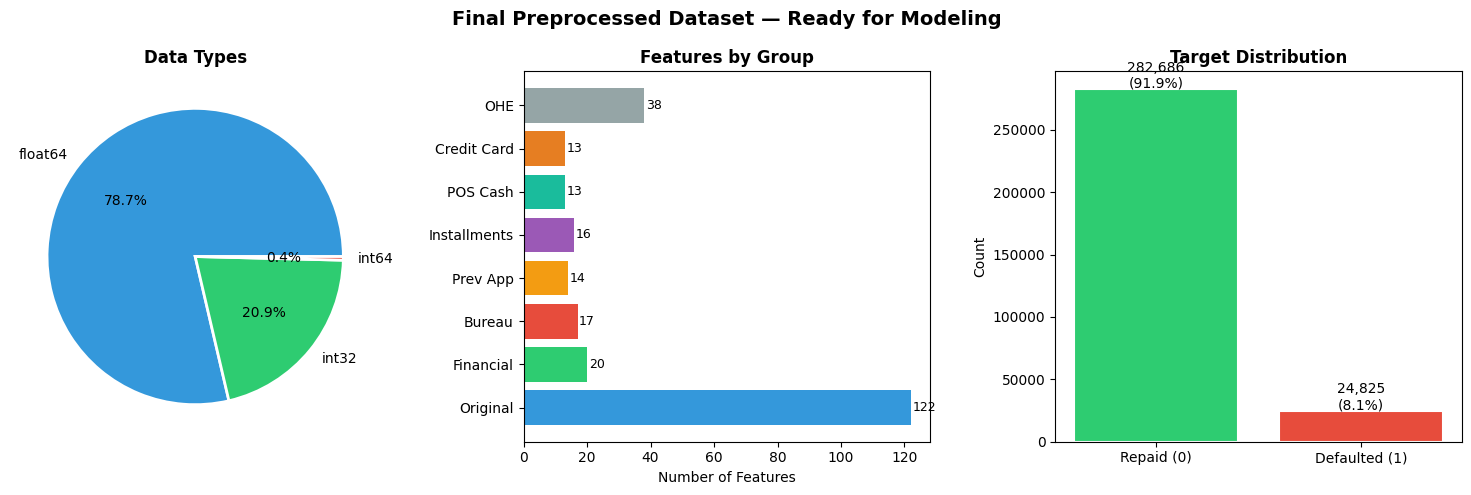

Plot saved!


In [8]:
print("=" * 50)
print("FINAL FEATURE SET OVERVIEW")
print("=" * 50)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Plot 1 — Data types breakdown
dtype_counts = df_encoded.dtypes.value_counts()
axes[0].pie(dtype_counts.values,
            labels=[str(x) for x in dtype_counts.index],
            autopct="%1.1f%%",
            colors=["#3498db", "#2ecc71", "#e74c3c"],
            wedgeprops={"edgecolor": "white", "linewidth": 2})
axes[0].set_title("Data Types", fontsize=12, fontweight="bold")

# Plot 2 — Feature groups
feature_groups = {
    "Original":      122,
    "Financial":     20,
    "Bureau":        17,
    "Prev App":      14,
    "Installments":  16,
    "POS Cash":      13,
    "Credit Card":   13,
    "OHE":           38,
}
colors = ["#3498db","#2ecc71","#e74c3c","#f39c12",
          "#9b59b6","#1abc9c","#e67e22","#95a5a6"]
axes[1].barh(list(feature_groups.keys()),
             list(feature_groups.values()),
             color=colors)
axes[1].set_xlabel("Number of Features")
axes[1].set_title("Features by Group", fontsize=12, fontweight="bold")
for i, v in enumerate(feature_groups.values()):
    axes[1].text(v + 0.5, i, str(v), va="center", fontsize=9)

# Plot 3 — Target distribution
axes[2].bar(["Repaid (0)", "Defaulted (1)"],
            [282686, 24825],
            color=["#2ecc71", "#e74c3c"],
            edgecolor="white", linewidth=1.5)
axes[2].set_title("Target Distribution", fontsize=12, fontweight="bold")
axes[2].set_ylabel("Count")
for i, (v, p) in enumerate([(282686, 91.9), (24825, 8.1)]):
    axes[2].text(i, v + 1000, f"{v:,}\n({p}%)",
                 ha="center", fontsize=10)

plt.suptitle("Final Preprocessed Dataset — Ready for Modeling",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(PROCESSED_DIR / "09_final_dataset_overview.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved!")